# Media Company Case Study

## Multiple Linear Regression

### Problem Statement:
A digital media company (similar to Voot, Hotstar, Netflix, etc.) had launched a show. Initially, the show got a good response, but then witnessed a decline in viewership. The company wants to figure out what went wrong.


### Approach:
We are concerned about determining the driver variable for show viewership. This is the case of prediction rather than projection where we are more interested in predicting the key driver variables and their impact rather than forcasting the results.

First we will list down the potential reasons for the decline in viewershp.<br>

The potential reasons could be:
1. Decline in the number of people coming to the platform
2. Fewer people watching the video
3. A Decrease in marketing spend?
4. Competitive shows, e.g. cricket/ IPL
5. Special holidays
6. Twist in the story


### Data
We have been given data for the period of 1 March 2017 to 19 May 2017.<br>
With Columns as<br> 
Views_show         : Number of times the show was viewed<br>
Visitors           : Number of visitors who browsed the platform, but not necessarily watched a video.<br>
Views_platform	   : Number of times a video was viewed on the platform<br>
Ad_impression	   : Proxy for marketing budget. Represents number of impressions generated by ads<br>
Cricket_match_india: If a cricket match was being played. 1 indicates match on a given day, 0 indicates there wasn't<br>
Character_A        : Describes presence of Character A. 1 indicates character A was in the episode, 0 indicates she/he wasn't

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read & Understanding the Data

In [2]:
media = pd.read_csv("mediacompany.csv")
del media['Unnamed: 7']
media.head()

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A
0,3/1/2017,183738,1260228,1706478,1060860448,0,0
1,3/2/2017,193763,1270561,1690727,1031846645,0,0
2,3/3/2017,210479,1248183,1726157,1010867575,0,0
3,3/4/2017,240061,1492913,1855353,1079194579,1,0
4,3/5/2017,446314,1594712,2041418,1357736987,0,0


In [3]:
media.tail()

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A
75,5/15/2017,313945,1808684,2226788,1398052759,1,0
76,5/16/2017,185689,1814227,2199844,1311961223,1,0
77,5/17/2017,142260,1755803,2225752,1248266254,1,0
78,5/18/2017,135871,1749654,2302789,1284859759,1,0
79,5/19/2017,108961,1746735,2279036,1246026846,1,0


# Inspect the data

In [4]:
media.shape
# (rows,columns)

(80, 7)

In [5]:
media.dtypes

Date                   object
Views_show              int64
Visitors                int64
Views_platform          int64
Ad_impression           int64
Cricket_match_india     int64
Character_A             int64
dtype: object

In [6]:
media['Date'] = pd.to_datetime(media['Date'])

In [7]:
media.dtypes #sort, fetch diff features from the datecolumn!

Date                   datetime64[ns]
Views_show                      int64
Visitors                        int64
Views_platform                  int64
Ad_impression                   int64
Cricket_match_india             int64
Character_A                     int64
dtype: object

In [8]:
media.head()

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A
0,2017-03-01,183738,1260228,1706478,1060860448,0,0
1,2017-03-02,193763,1270561,1690727,1031846645,0,0
2,2017-03-03,210479,1248183,1726157,1010867575,0,0
3,2017-03-04,240061,1492913,1855353,1079194579,1,0
4,2017-03-05,446314,1594712,2041418,1357736987,0,0


In [9]:
media[['Views_show', 'Visitors', 'Views_platform', 'Ad_impression']].describe()

,Views_show,Visitors,Views_platform,Ad_impression
count,80.000000,8.000000e+01,8.000000e+01,8.000000e+01
mean,289902.625000,1.699066e+06,2.222401e+06,1.442374e+09
std,154924.323585,2.311571e+05,2.913510e+05,2.983186e+08
min,102520.000000,1.248183e+06,1.690727e+06,1.010868e+09
25%,185353.250000,1.550766e+06,2.010816e+06,1.207911e+09
50%,235807.000000,1.698843e+06,2.226270e+06,1.385931e+09
75%,350079.000000,1.817895e+06,2.388837e+06,1.632416e+09
max,758631.000000,2.344650e+06,3.064422e+06,2.424203e+09


In [10]:
media.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 80 non-null     datetime64[ns]
 1   Views_show           80 non-null     int64         
 2   Visitors             80 non-null     int64         
 3   Views_platform       80 non-null     int64         
 4   Ad_impression        80 non-null     int64         
 5   Cricket_match_india  80 non-null     int64         
 6   Character_A          80 non-null     int64         
dtypes: datetime64[ns](1), int64(6)
memory usage: 4.5 KB


# Missing Value and Outlier Check

In [11]:
media.isnull().sum()

Date                   0
Views_show             0
Visitors               0
Views_platform         0
Ad_impression          0
Cricket_match_india    0
Character_A            0
dtype: int64

In [12]:
media.head()

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A
0,2017-03-01,183738,1260228,1706478,1060860448,0,0
1,2017-03-02,193763,1270561,1690727,1031846645,0,0
2,2017-03-03,210479,1248183,1726157,1010867575,0,0
3,2017-03-04,240061,1492913,1855353,1079194579,1,0
4,2017-03-05,446314,1594712,2041418,1357736987,0,0


<Axes: ylabel='Views_show'>

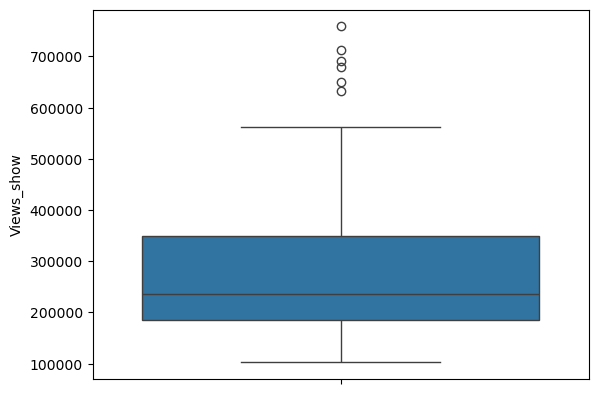

In [13]:
sns.boxplot(media['Views_show'])

<Axes: ylabel='Visitors'>

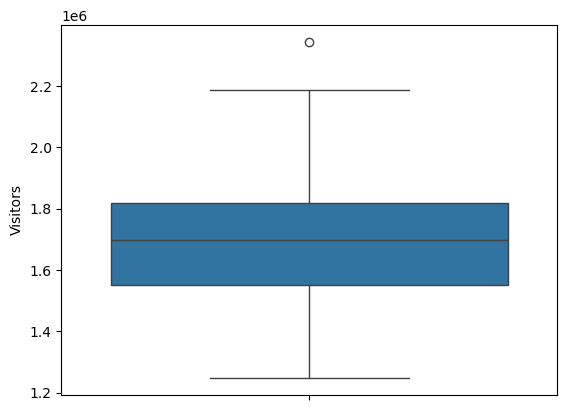

In [14]:
sns.boxplot(media['Visitors'])

<Axes: ylabel='Views_platform'>

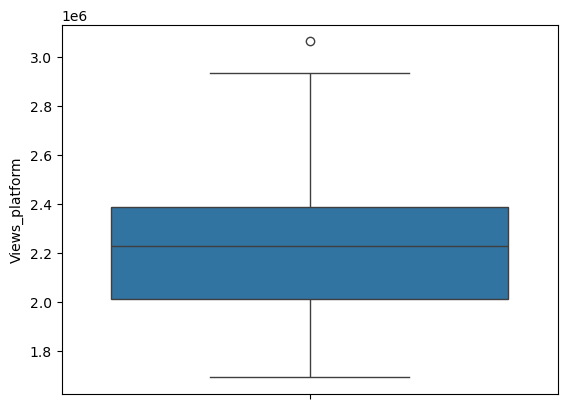

In [15]:
sns.boxplot(media['Views_platform'])

<Axes: ylabel='Ad_impression'>

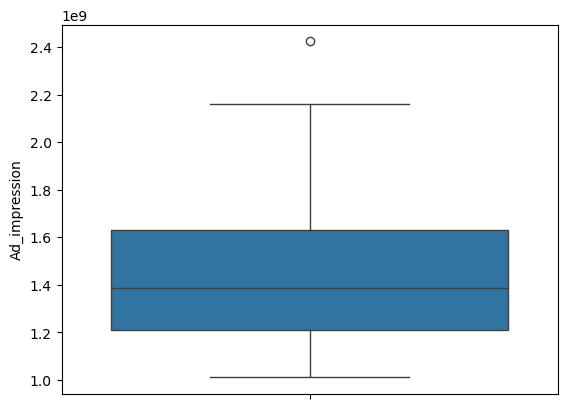

In [16]:
sns.boxplot(media['Ad_impression'])

In [17]:
media.head()

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A
0,2017-03-01,183738,1260228,1706478,1060860448,0,0
1,2017-03-02,193763,1270561,1690727,1031846645,0,0
2,2017-03-03,210479,1248183,1726157,1010867575,0,0
3,2017-03-04,240061,1492913,1855353,1079194579,1,0
4,2017-03-05,446314,1594712,2041418,1357736987,0,0


In [18]:
media['day_of_week'] = media['Date'].dt.dayofweek

In [19]:
media.head()

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A,day_of_week
0,2017-03-01,183738,1260228,1706478,1060860448,0,0,2
1,2017-03-02,193763,1270561,1690727,1031846645,0,0,3
2,2017-03-03,210479,1248183,1726157,1010867575,0,0,4
3,2017-03-04,240061,1492913,1855353,1079194579,1,0,5
4,2017-03-05,446314,1594712,2041418,1357736987,0,0,6


In [20]:
# year, month, quarter, day of week, weekday/weekend flag

# Exploratory Data Analysis

In [21]:
media.head()

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A,day_of_week
0,2017-03-01,183738,1260228,1706478,1060860448,0,0,2
1,2017-03-02,193763,1270561,1690727,1031846645,0,0,3
2,2017-03-03,210479,1248183,1726157,1010867575,0,0,4
3,2017-03-04,240061,1492913,1855353,1079194579,1,0,5
4,2017-03-05,446314,1594712,2041418,1357736987,0,0,6


<Axes: xlabel='Date'>

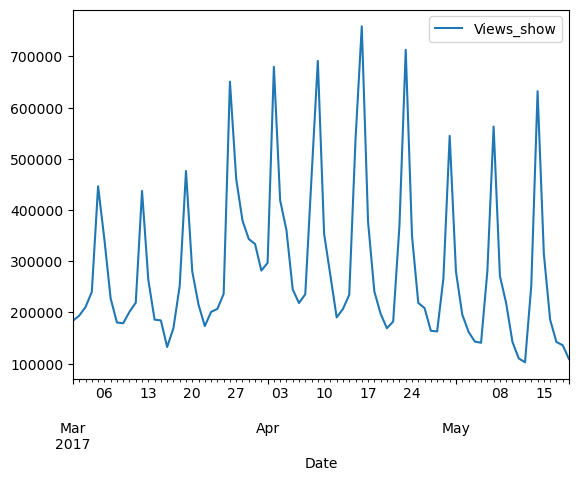

In [22]:
media.plot.line(x='Date',y='Views_show')

In [23]:
# inference : there's some pattern in the data!

In [24]:
media.head()

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A,day_of_week
0,2017-03-01,183738,1260228,1706478,1060860448,0,0,2
1,2017-03-02,193763,1270561,1690727,1031846645,0,0,3
2,2017-03-03,210479,1248183,1726157,1010867575,0,0,4
3,2017-03-04,240061,1492913,1855353,1079194579,1,0,5
4,2017-03-05,446314,1594712,2041418,1357736987,0,0,6


In [25]:
# for each day_of_week,number of views

<Axes: xlabel='day_of_week', ylabel='Views_show'>

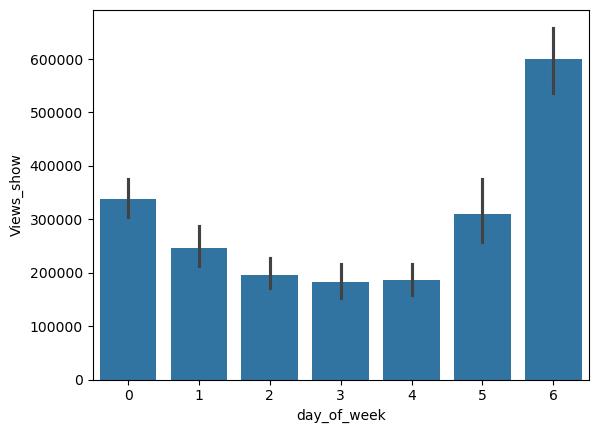

In [26]:
sns.barplot(data=media,x='day_of_week',y='Views_show')

In [27]:
# 6 : Sunday gets the most views!

In [28]:
# 5,6 (Sat,Sun) - 1
# 01234 - 0

In [29]:
di = {5:1,6:1,0:0,1:0,2:0,3:0,4:0}
media['weekend'] = media['day_of_week'].map(di)

In [30]:
media.head()

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A,day_of_week,weekend
0,2017-03-01,183738,1260228,1706478,1060860448,0,0,2,0
1,2017-03-02,193763,1270561,1690727,1031846645,0,0,3,0
2,2017-03-03,210479,1248183,1726157,1010867575,0,0,4,0
3,2017-03-04,240061,1492913,1855353,1079194579,1,0,5,1
4,2017-03-05,446314,1594712,2041418,1357736987,0,0,6,1


<Axes: xlabel='weekend', ylabel='Views_show'>

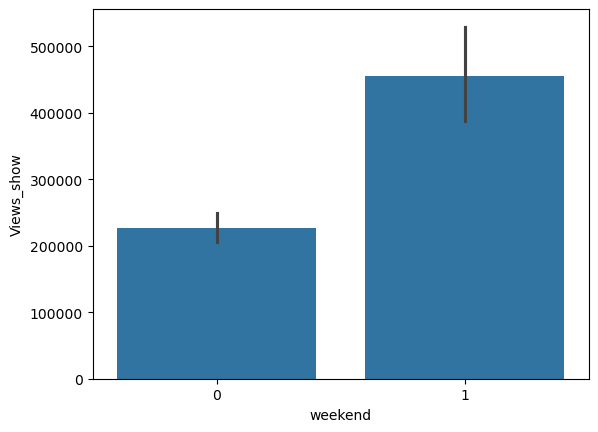

In [31]:
sns.barplot(data=media,x='weekend',y='Views_show')

In [32]:
# Viewership is HIGH on the weekends!

In [33]:
# 1) Ad impression, views_shows
# 2) Visitors, views_shows
# 3) Views_platform, views_shows
# both numerical columns

# -- Optional
# 4) India Match,views_shows
# 5) Character A,views_shows
# caetgorical, numerical column

In [34]:
media.columns

Index(['Date', 'Views_show', 'Visitors', 'Views_platform', 'Ad_impression',
       'Cricket_match_india', 'Character_A', 'day_of_week', 'weekend'],
      dtype='object')

<Axes: xlabel='Ad_impression', ylabel='Views_show'>

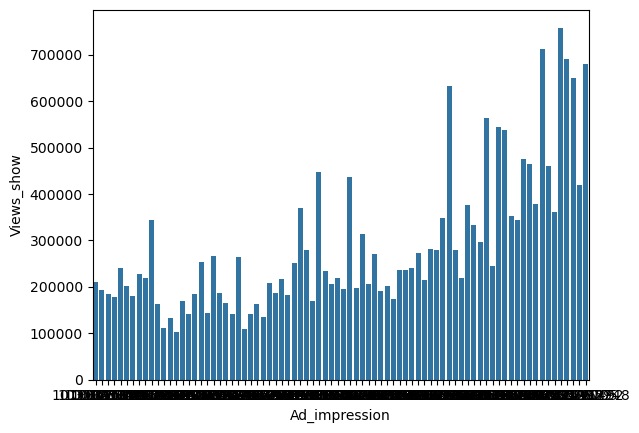

In [35]:
sns.barplot(data=media,x='Ad_impression',y='Views_show')

<Axes: xlabel='Ad_impression'>

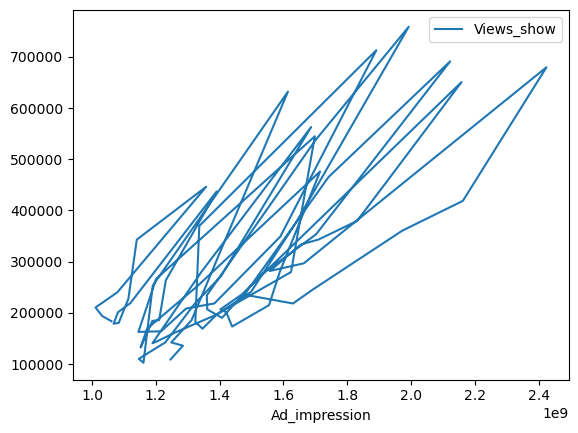

In [36]:
media.plot.line(x='Ad_impression',y='Views_show')

<Axes: >

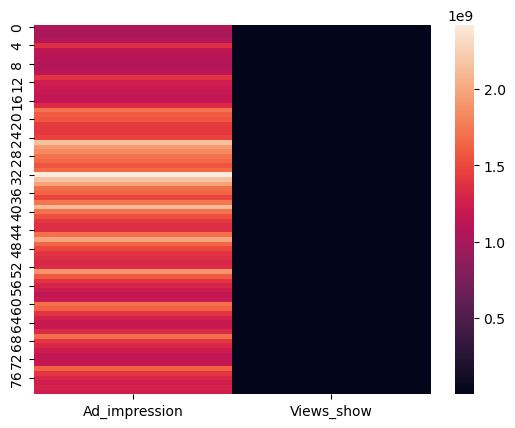

In [49]:
sns.heatmap(media[["Ad_impression","Views_show"]])

<Axes: xlabel='Ad_impression', ylabel='Views_show'>

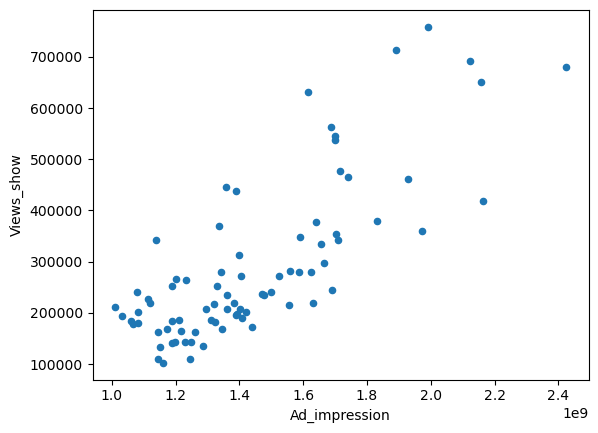

In [37]:
media.plot.scatter(x='Ad_impression', y='Views_show')

<Axes: xlabel='Visitors'>

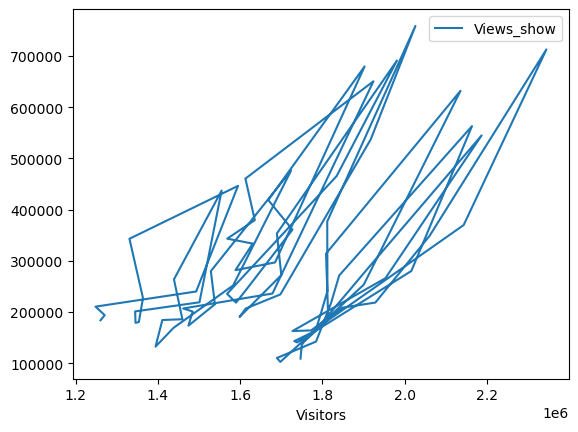

In [44]:
media.plot.line(x='Visitors',y='Views_show')

<Axes: xlabel='Cricket_match_india', ylabel='Views_show'>

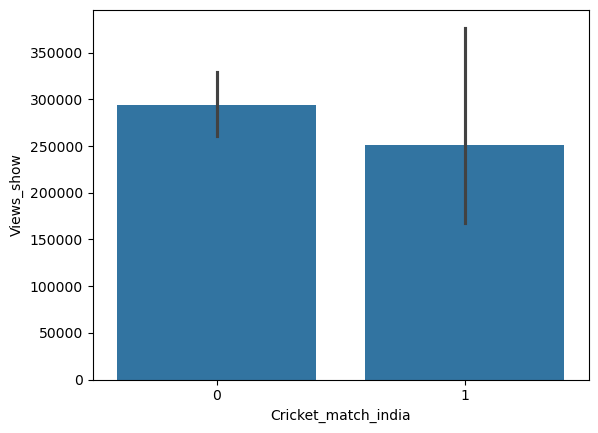

In [46]:
sns.barplot(data=media,x='Cricket_match_india',y='Views_show')

In [45]:
media.columns

Index(['Date', 'Views_show', 'Visitors', 'Views_platform', 'Ad_impression',
       'Cricket_match_india', 'Character_A', 'day_of_week', 'weekend'],
      dtype='object')

<Axes: xlabel='Character_A', ylabel='Views_show'>

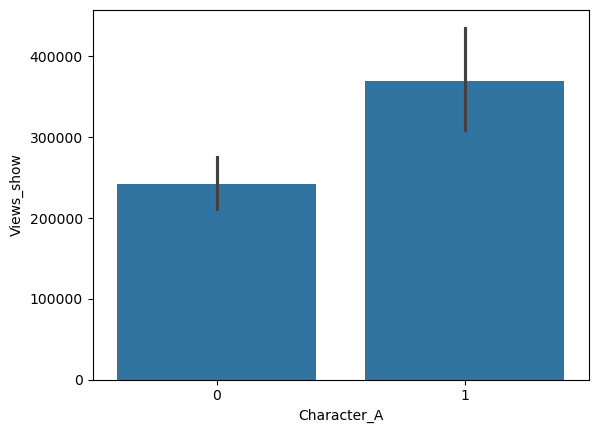

In [47]:
sns.barplot(data=media,x='Character_A',y='Views_show')